In [34]:
"""
Improved checkpoint script for retail sales forecasting
- Adds lag & rolling features
- Frequency encoding for high-cardinality categoricals
- log1p target; LightGBM training with time-based split and early stopping
- Saves model and feature list to /mnt/data

Usage: run this script in the same environment as your CSV dataset.
"""

import os
import gc
import time
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
import lightgbm as lgb

warnings.filterwarnings('ignore')

# ---------- Config ----------
DATA_PATH = '/content/retail_store_inventory.csv'
MODEL_OUT = '/content/untitled11_checkpoint_lgb.txt'
FEATURES_OUT = '/content/untitled11_checkpoint_features.json'
TARGET = 'Units Sold'
DATE_COL = 'Date'
GROUP_KEYS = ['Product ID', 'Store ID']
TEST_SIZE_RATIO = 0.2
SEED = 42

# ---------- Helpers ----------

def rmsle_raw(y_true, y_pred):
    y_true = np.maximum(0, y_true)
    y_pred = np.maximum(0, y_pred)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))


# ---------- Load ----------
def load_data(path=DATA_PATH):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Data not found at {path}")
    df = pd.read_csv(path)
    if DATE_COL in df.columns:
        df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')
    else:
        raise RuntimeError(f"Date column '{DATE_COL}' not found")
    return df


# ---------- Feature engineering ----------
LAGS = [1, 7, 14, 28]
ROLL_WINDOWS = [7, 14]


def create_time_features(df):
    df = df.copy()
    df['day_of_week'] = df[DATE_COL].dt.dayofweek.astype('int8')
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype('int8')
    df['month'] = df[DATE_COL].dt.month.astype('int8')
    df['week'] = df[DATE_COL].dt.isocalendar().week.astype('int16')
    return df


def frequency_encoding(df, cols):
    for c in cols:
        df[c + '_freq'] = df[c].map(df[c].value_counts(normalize=True))
    return df


def make_lag_features(df, group_cols, target_col='y'):
    df = df.sort_values(group_cols + [DATE_COL])

    def _make(g):
        g = g.sort_values(DATE_COL)
        for lag in LAGS:
            g[f'lag_{lag}'] = g[target_col].shift(lag)
        for w in ROLL_WINDOWS:
            g[f'roll_mean_{w}'] = g[target_col].shift(1).rolling(window=w, min_periods=1).mean()
            g[f'roll_std_{w}'] = g[target_col].shift(1).rolling(window=w, min_periods=1).std().fillna(0)
        g['days_since_prev'] = (g[DATE_COL] - g[DATE_COL].shift(1)).dt.days.fillna(0)
        return g

    df = df.groupby(group_cols, group_keys=False).apply(_make).reset_index(drop=True)
    return df


# ---------- Main pipeline ----------

def main():
    t0 = time.time()
    df = load_data()
    print('Loaded', len(df), 'rows')

    # sanitize columns we will use
    need_cols = [DATE_COL, 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level',
                 'Units Sold', 'Units Ordered', 'Price', 'Discount', 'Competitor Pricing',
                 'Weather Condition', 'Holiday/Promotion', 'Seasonality']
    # keep columns present
    keep = [c for c in need_cols if c in df.columns]
    df = df[keep].copy()

    # drop rows with missing date or target
    df = df.dropna(subset=[DATE_COL, TARGET])

    # sort
    df = df.sort_values(GROUP_KEYS + [DATE_COL]).reset_index(drop=True)

    # log1p target
    df['y'] = np.log1p(df[TARGET].astype(float))

    # fill numeric NAs with medians
    num_fill_cols = [c for c in ['Price', 'Competitor Pricing', 'Discount', 'Inventory Level', 'Units Ordered'] if c in df.columns]
    for c in num_fill_cols:
        df[c] = df[c].fillna(df[c].median())

    # time features
    df = create_time_features(df)

    # frequency encoding for high-cardinality
    enc_cols = [c for c in ['Store ID', 'Product ID'] if c in df.columns]
    df = frequency_encoding(df, enc_cols)

    # sku-store pair freq
    if 'Store ID' in df.columns and 'Product ID' in df.columns:
        df['sku_store'] = df['Product ID'].astype(str) + '|' + df['Store ID'].astype(str)
        df['sku_store_freq'] = df['sku_store'].map(df['sku_store'].value_counts(normalize=True))

    # lag features (group by Product ID + Store ID)
    df = make_lag_features(df, GROUP_KEYS, target_col='y')

    # fill lag NAs
    lag_cols = [c for c in df.columns if c.startswith('lag_') or c.startswith('roll_')]
    for c in lag_cols:
        df[c] = df[c].fillna(df[c].median()).fillna(0)

    # categorical type casting for LightGBM
    cat_cols = [c for c in ['Category', 'Region', 'Weather Condition', 'Seasonality'] if c in df.columns]
    for c in cat_cols:
        df[c] = df[c].astype('category')

    # select features
    features = []
    base_nums = [c for c in ['Inventory Level', 'Price', 'Discount', 'Competitor Pricing', 'Units Ordered'] if c in df.columns]
    features += base_nums
    features += lag_cols
    features += [c for c in ['Store ID_freq', 'Product ID_freq', 'sku_store_freq', 'day_of_week', 'is_weekend', 'month', 'week', 'days_since_prev'] if c in df.columns]
    features += cat_cols

    # deduplicate and ensure present
    features = [f for f in pd.unique(features) if f in df.columns]
    print('Final features count:', len(features))

    # final sort by date and split
    df = df.sort_values(DATE_COL).reset_index(drop=True)
    split_idx = int(len(df) * (1.0 - TEST_SIZE_RATIO))
    train = df.iloc[:split_idx].reset_index(drop=True)
    valid = df.iloc[split_idx:].reset_index(drop=True)

    X_train = train[features]
    y_train = train['y']
    X_valid = valid[features]
    y_valid = valid['y']

    # LightGBM dataset
    cat_feats_lgb = [c for c in cat_cols if c in features]
    lgb_train = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_feats_lgb, free_raw_data=False)
    lgb_valid = lgb.Dataset(X_valid, label=y_valid, categorical_feature=cat_feats_lgb, reference=lgb_train, free_raw_data=False)

    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'learning_rate': 0.05,
        'num_leaves': 64,
        'max_depth': 9,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'min_child_samples': 20,
        'verbose': -1,
        'seed': SEED
    }

    print('Training LightGBM...')
    evals_result = {}
    bst = lgb.train(
        params,
        lgb_train,
        num_boost_round=3000,
        valid_sets=[lgb_train, lgb_valid],
        valid_names=['train', 'valid'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100),
            lgb.log_evaluation(period=100)
        ]
    )

    # predict back to original scale
    pred_log = bst.predict(X_valid, num_iteration=bst.best_iteration)
    pred = np.expm1(pred_log)
    y_true = np.expm1(y_valid)

    rmse = np.sqrt(mean_squared_error(y_true, pred))
    mae = mean_absolute_error(y_true, pred)
    rmsle_val = rmsle_raw(y_true, pred)

    print(f"Best iter: {bst.best_iteration}")
    print(f"Validation RMSE: {rmse:.4f}, MAE: {mae:.4f}, RMSLE: {rmsle_val:.4f}")

    # feature importance
    fi = pd.Series(bst.feature_importance(importance_type='gain'), index=features).sort_values(ascending=False)
    print('\nTop features:\n', fi.head(20).to_string())

    # save model and features
    bst.save_model(MODEL_OUT)
    with open(FEATURES_OUT, 'w') as f:
        json.dump(features, f)

    print(f"Model saved to {MODEL_OUT}")
    print(f"Feature list saved to {FEATURES_OUT}")
    print('Elapsed', time.time() - t0)

    # cleanup
    del lgb_train, lgb_valid
    gc.collect()


if __name__ == '__main__':
    main()

Loaded 73100 rows
Final features count: 25
Training LightGBM...
Training until validation scores don't improve for 100 rounds
[100]	train's rmse: 0.918883	valid's rmse: 0.961351
Early stopping, best iteration is:
[72]	train's rmse: 0.928679	valid's rmse: 0.96087
Best iter: 72
Validation RMSE: 96.8388, MAE: 73.4782, RMSLE: 0.9609

Top features:
 Inventory Level       195122.497815
lag_7                   2880.863016
lag_1                   2586.376083
lag_28                  2580.629749
lag_14                  2482.619834
roll_std_7              2391.567252
roll_mean_14            2292.526350
Competitor Pricing      2262.029400
roll_mean_7             2159.190528
roll_std_14             2129.806605
Price                   1839.090346
Units Ordered           1680.475838
week                    1602.463499
Discount                 589.212290
day_of_week              587.661903
month                    579.016039
Category                 419.060970
Weather Condition        332.160549
Regio

In [35]:
# -*- coding: utf-8 -*-
"""Cleaned minimal edits of model (1).py
- Moved baseline evaluation inside main() to avoid NameError.
- Removed duplicate top-level blocks while preserving original behavior.
- No major logic changes.
"""

import os, gc, time, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
import lightgbm as lgb

warnings.filterwarnings('ignore')

# ---------- Config ----------
DATA_PATH = '/content/retail_store_inventory.csv'
MODEL_OUT = '/content/untitled12_checkpoint_lgb.txt'
FEATURES_OUT = '/content/untitled12_checkpoint_features.json'
TARGET = 'Units Sold'
DATE_COL = 'Date'
GROUP_KEYS = ['Product ID', 'Store ID']
TEST_SIZE_RATIO = 0.2
SEED = 42

# ---------- Helpers ----------
def rmsle_raw(y_true, y_pred):
    y_true = np.maximum(0, y_true)
    y_pred = np.maximum(0, y_pred)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

# ---------- Feature engineering ----------
LAGS = [1, 7, 14, 28]
ROLL_WINDOWS = [7, 14]

def create_time_features(df):
    df = df.copy()
    df['day_of_week'] = df[DATE_COL].dt.dayofweek.astype('int8')
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype('int8')
    df['month'] = df[DATE_COL].dt.month.astype('int8')
    df['week'] = df[DATE_COL].dt.isocalendar().week.astype('int16')
    return df

def frequency_encoding(df, cols):
    for c in cols:
        df[c + '_freq'] = df[c].map(df[c].value_counts(normalize=True))
    return df

def make_lag_features(df, group_cols, target_col='y'):
    df = df.sort_values(group_cols + [DATE_COL])
    def _make(g):
        g = g.sort_values(DATE_COL)
        for lag in LAGS:
            g[f'lag_{lag}'] = g[target_col].shift(lag)
        for w in ROLL_WINDOWS:
            g[f'roll_mean_{w}'] = g[target_col].shift(1).rolling(window=w, min_periods=1).mean()
            g[f'roll_std_{w}'] = g[target_col].shift(1).rolling(window=w, min_periods=1).std().fillna(0)
        g['days_since_prev'] = (g[DATE_COL] - g[DATE_COL].shift(1)).dt.days.fillna(0)
        return g
    df = df.groupby(group_cols, group_keys=False).apply(_make).reset_index(drop=True)
    return df

def load_data(path=DATA_PATH):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Data not found at {path}")
    df = pd.read_csv(path)
    if DATE_COL in df.columns:
        df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')
    else:
        raise RuntimeError(f"Date column '{DATE_COL}' not found")
    return df

def main():
    t0 = time.time()
    df = load_data()
    print('Loaded', len(df), 'rows')

    # ---------- WEEKLY AGGREGATION ----------
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')
    df = df.dropna(subset=[DATE_COL, TARGET])

    weekly = (
        df
        .groupby(['Product ID','Store ID', pd.Grouper(key=DATE_COL, freq='W')])
        .agg({
            'Units Sold': 'sum',
            'Inventory Level': 'mean',
            'Units Ordered': 'sum',
            'Price': 'mean',
            'Discount': 'max',
            'Competitor Pricing': 'mean',
            'Category': 'first',
            'Region': 'first',
            'Weather Condition': 'first',
            'Seasonality': 'first'
        })
        .reset_index()
    )

    dfw = weekly.copy()
    print('After weekly aggregation:', len(dfw), 'rows')

    # sanitize columns we will use
    need_cols = [DATE_COL, 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level',
                 'Units Sold', 'Units Ordered', 'Price', 'Discount', 'Competitor Pricing',
                 'Weather Condition', 'Holiday/Promotion', 'Seasonality']
    keep = [c for c in need_cols if c in dfw.columns]
    dfw = dfw[keep].copy()

    # drop rows with missing date or target
    dfw = dfw.dropna(subset=[DATE_COL, TARGET])

    # sort
    dfw = dfw.sort_values(GROUP_KEYS + [DATE_COL]).reset_index(drop=True)

    # log1p target
    dfw['y'] = np.log1p(dfw[TARGET].astype(float))

    # fill numeric NAs with medians
    num_fill_cols = [c for c in ['Price', 'Competitor Pricing', 'Discount', 'Inventory Level', 'Units Ordered'] if c in dfw.columns]
    for c in num_fill_cols:
        dfw[c] = dfw[c].fillna(dfw[c].median())

    # time features
    dfw = create_time_features(dfw)

    # frequency encoding for high-cardinality
    enc_cols = [c for c in ['Store ID', 'Product ID'] if c in dfw.columns]
    if enc_cols:
        dfw = frequency_encoding(dfw, enc_cols)

    # sku-store pair freq
    if 'Store ID' in dfw.columns and 'Product ID' in dfw.columns:
        dfw['sku_store'] = dfw['Product ID'].astype(str) + '|' + dfw['Store ID'].astype(str)
        dfw['sku_store_freq'] = dfw['sku_store'].map(dfw['sku_store'].value_counts(normalize=True))

    # lag features (group by Product ID + Store ID)
    dfw = make_lag_features(dfw, GROUP_KEYS, target_col='y')

    # fill lag NAs
    lag_cols = [c for c in dfw.columns if c.startswith('lag_') or c.startswith('roll_')]
    for c in lag_cols:
        dfw[c] = dfw[c].fillna(dfw[c].median()).fillna(0)

    # categorical type casting for LightGBM
    cat_cols = [c for c in ['Category', 'Region', 'Weather Condition', 'Seasonality'] if c in dfw.columns]
    for c in cat_cols:
        dfw[c] = dfw[c].astype('category')

    # select features
    features = []
    base_nums = [c for c in ['Inventory Level', 'Price', 'Discount', 'Competitor Pricing', 'Units Ordered'] if c in dfw.columns]
    features += base_nums
    features += lag_cols
    features += [c for c in ['Store ID_freq', 'Product ID_freq', 'sku_store_freq', 'day_of_week', 'is_weekend', 'month', 'week', 'days_since_prev'] if c in dfw.columns]
    features += cat_cols
    features = [f for f in pd.unique(features) if f in dfw.columns]
    print('Final features count:', len(features))

    # final sort by date and split
    dfw = dfw.sort_values(DATE_COL).reset_index(drop=True)
    split_idx = int(len(dfw) * (1.0 - TEST_SIZE_RATIO))
    train = dfw.iloc[:split_idx].reset_index(drop=True)
    valid = dfw.iloc[split_idx:].reset_index(drop=True)

    X_train = train[features]
    y_train = train['y']
    X_valid = valid[features]
    y_valid = valid['y']

    # LightGBM dataset
    cat_feats_lgb = [c for c in cat_cols if c in features]
    lgb_train = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_feats_lgb, free_raw_data=False)
    lgb_valid = lgb.Dataset(X_valid, label=y_valid, categorical_feature=cat_feats_lgb, reference=lgb_train, free_raw_data=False)

    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'learning_rate': 0.05,
        'num_leaves': 64,
        'max_depth': 9,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'min_child_samples': 20,
        'verbose': -1,
        'seed': SEED
    }

    print('Training LightGBM...')
    bst = lgb.train(
        params,
        lgb_train,
        num_boost_round=3000,
        valid_sets=[lgb_train, lgb_valid],
        valid_names=['train', 'valid'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100),
            lgb.log_evaluation(period=100)
        ]
    )

    # predict back to original scale
    pred_log = bst.predict(X_valid, num_iteration=bst.best_iteration)
    pred = np.expm1(pred_log)
    y_true = np.expm1(y_valid)

    rmse = np.sqrt(mean_squared_error(y_true, pred))
    mae = mean_absolute_error(y_true, pred)
    rmsle_val = rmsle_raw(y_true, pred)

    print(f"Best iter: {bst.best_iteration}")
    print(f"Validation RMSE: {rmse:.4f}, MAE: {mae:.4f}, RMSLE: {rmsle_val:.4f}")

    # feature importance
    fi = pd.Series(bst.feature_importance(importance_type='gain'), index=features).sort_values(ascending=False)
    print('\nTop features:\n', fi.head(20).to_string())

    # save model and features
    bst.save_model(MODEL_OUT)
    with open(FEATURES_OUT, 'w') as f:
        json.dump(features, f)

    print(f"Model saved to {MODEL_OUT}")
    print(f"Feature list saved to {FEATURES_OUT}")
    print('Elapsed', time.time() - t0)

    # ===== Baseline: Demand Forecast (weekly) =====
    if "Demand Forecast" in valid.columns:
        df_base = valid.dropna(subset=["Demand Forecast"]).copy()

        y_true_base = np.expm1(df_base["y"].values)  # weekly Units Sold sum scale
        y_pred_base = df_base["Demand Forecast"].astype(float).values

        rmse_base = np.sqrt(mean_squared_error(y_true_base, y_pred_base))
        mae_base = mean_absolute_error(y_true_base, y_pred_base)
        rmsle_base = rmsle_raw(y_true_base, y_pred_base)

        print("\n[Baseline: Demand Forecast] (weekly, same valid period)")
        print(f"RMSE: {rmse_base:.4f}, MAE: {mae_base:.4f}, RMSLE: {rmsle_base:.4f}")
    else:
        print("\nNo weekly Demand Forecast available.")

    # cleanup
    del lgb_train, lgb_valid
    gc.collect()

if __name__ == '__main__':
    main()


Loaded 73100 rows
After weekly aggregation: 10600 rows
Final features count: 25
Training LightGBM...
Training until validation scores don't improve for 100 rounds
[100]	train's rmse: 0.220429	valid's rmse: 0.581779
[200]	train's rmse: 0.189975	valid's rmse: 0.582555
Early stopping, best iteration is:
[107]	train's rmse: 0.217867	valid's rmse: 0.581425
Best iter: 107
Validation RMSE: 272.9201, MAE: 206.9315, RMSLE: 0.5814

Top features:
 Inventory Level       3344.520736
days_since_prev       1580.337322
Units Ordered          292.746583
roll_std_7             258.066705
lag_1                  244.603205
week                   175.737495
Price                  172.682840
roll_std_14            171.130904
Competitor Pricing     139.918166
lag_7                  134.199296
lag_14                 133.415134
roll_mean_7            133.239181
roll_mean_14           127.190930
lag_28                 121.794677
month                   41.027683
Discount                25.041039
Region         

In [36]:
# 只讀取已存結果的「兩模型乾淨總結 cell」
# 不會重訓、不會重算 features。執行後直接在 output 顯示 summary。

import os, json, glob, numpy as np
import lightgbm as lgb
from pathlib import Path
from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error

ROOT = Path("/content")
# patterns to search for models, feature-lists, and metrics
model_patterns = ["**/*checkpoint*.txt", "**/*.model", "**/*.txt"]
feature_patterns = ["**/*features*.json", "**/features_*.json"]
metrics_patterns = ["**/*metrics*.json", "**/metrics.json", "**/*eval*.csv", "**/*valid_preds*.npy"]

def rmsle_raw(y_true, y_pred):
    y_true = np.maximum(0, np.array(y_true))
    y_pred = np.maximum(0, np.array(y_pred))
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

def safe_load_json(p):
    try:
        return json.load(open(p, "r"))
    except Exception:
        return None

def find_files(patterns):
    files = []
    for pat in patterns:
        files.extend([p for p in ROOT.glob(pat) if p.is_file()])
    # unique and sort
    uniq = sorted({str(p) for p in files})
    return [Path(p) for p in uniq]

model_files = find_files(model_patterns)
feature_files = find_files(feature_patterns)
metrics_files = find_files(metrics_patterns)

print("="*70)
print("Two-model Summary (read-only)")
print("="*70)
print(f"Search root: {ROOT}")
print()

if not model_files:
    print("No model files found under /content with common patterns.")
    print("Looked for patterns:", model_patterns)
    print()
else:
    print(f"Found {len(model_files)} model file(s):")
    for p in model_files:
        print(" -", p)
    print()

# helper to try read feature list near a model
def find_feature_for_model(mpath):
    # look for features file in same folder or global feature files that contain 'checkpoint' or similar
    folder = mpath.parent
    candidates = list(folder.glob("*features*.json")) + [f for f in feature_files if "checkpoint" in f.name.lower()]
    return candidates[0] if candidates else (feature_files[0] if feature_files else None)

# helper to find metrics near model
def find_metrics_for_model(mpath):
    folder = mpath.parent
    candidates = list(folder.glob("*metrics*.json")) + list(folder.glob("*eval*.csv")) + list(folder.glob("*valid_preds*.npy"))
    return candidates[0] if candidates else (metrics_files[0] if metrics_files else None)

def print_model_summary(mpath):
    print("-"*70)
    print(f"Model file: {mpath}")
    # try load model
    try:
        bst = lgb.Booster(model_file=str(mpath))
        print("Model loaded: YES (LightGBM)")
        # best_iteration may be available as attribute; safe access
        best_it = getattr(bst, "best_iteration", None)
        try:
            # sometimes best_iteration is stored as int in attr()
            if best_it is None:
                best_it = bst.attr("best_iteration") if "best_iteration" in bst.attr_keys() else None
        except Exception:
            pass
        print("Best iteration       :", best_it)
        try:
            print("Num trees            :", bst.num_trees())
        except Exception:
            pass
        # feature importance
        try:
            fn = bst.feature_name()
            fi = bst.feature_importance(importance_type="gain")
            fi_pairs = sorted(zip(fn, fi), key=lambda x: x[1], reverse=True)[:10]
            print("Top features (by gain):")
            for i,(n,v) in enumerate(fi_pairs,1):
                print(f" {i:>2}. {n:<28} {v:,.0f}")
        except Exception:
            print("Feature importance  : not available from model file")
    except Exception as e:
        print("Model loaded: NO (error) ->", e)

    # feature list file
    feat = find_feature_for_model(mpath)
    if feat:
        fl = safe_load_json(feat)
        print("Feature list file     :", feat.name)
        if isinstance(fl, list):
            print(" Total features       :", len(fl))
            print(" Sample features      :", fl[:10])
        else:
            print(" Feature list content not a simple list or couldn't parse.")
    else:
        print("Feature list file     : Not found")

    # metrics detection
    metr = find_metrics_for_model(mpath)
    if metr:
        print("Found metrics file    :", metr.name)
        if metr.suffix.lower() == ".json":
            mj = safe_load_json(metr)
            if isinstance(mj, dict):
                # common keys: rmse, mae, rmsle, val_rmse, best_iter, etc.
                known_keys = {k:v for k,v in mj.items() if isinstance(v,(int,float,str))}
                if known_keys:
                    print(" Metrics from JSON:")
                    for k,v in known_keys.items():
                        print(f"  - {k}: {v}")
                else:
                    print(" JSON loaded but no numeric metrics found at top-level.")
            else:
                print(" Unrecognized JSON structure.")
        elif metr.suffix.lower() == ".csv":
            try:
                import pandas as pd
                dfm = pd.read_csv(metr)
                print(" CSV metrics preview:")
                print(dfm.head().to_string(index=False))
            except Exception as e:
                print(" Could not read CSV metrics:", e)
        elif metr.suffix.lower() == ".npy":
            try:
                arr = np.load(metr)
                print(" Found numpy array (maybe preds). shape:", arr.shape)
            except Exception:
                print(" Could not load .npy")
        else:
            print(" Unknown metrics file type.")
    else:
        print("Metrics file          : Not found near model or in repo.")

    print("-"*70)
    print()

# If there are at least two model files, assume they correspond to your two models (daily/weekly).
# If only one, we still print its summary and note that second is missing.
if model_files:
    # prefer showing two: if more than two, show all but label first two specially
    for idx, mf in enumerate(model_files, start=1):
        label = f"Model #{idx}"
        # Heuristic labeling based on filename
        name_low = mf.name.lower()
        if "week" in name_low or "weekly" in name_low:
            label += " (weekly)"
        elif "day" in name_low or "daily" in name_low:
            label += " (daily)"
        print(f"*** {label} summary ***")
        print_model_summary(mf)

# If fewer than 2 models found, explicitly state that and show suggestions
if len(model_files) < 2:
    print("NOTE: fewer than 2 model files found.")
    print("If you have a second trained model, please upload it to /content or name it with 'daily'/'weekly' or 'checkpoint' so this cell finds it.")
    print()

print("END OF SUMMARY")
print("="*70)


Two-model Summary (read-only)
Search root: /content

Found 2 model file(s):
 - /content/untitled11_checkpoint_lgb.txt
 - /content/untitled12_checkpoint_lgb.txt

*** Model #1 summary ***
----------------------------------------------------------------------
Model file: /content/untitled11_checkpoint_lgb.txt
Model loaded: YES (LightGBM)
Best iteration       : -1
Num trees            : 72
Top features (by gain):
  1. Inventory_Level              195,122
  2. lag_7                        2,881
  3. lag_1                        2,586
  4. lag_28                       2,581
  5. lag_14                       2,483
  6. roll_std_7                   2,392
  7. roll_mean_14                 2,293
  8. Competitor_Pricing           2,262
  9. roll_mean_7                  2,159
 10. roll_std_14                  2,130
Feature list file     : untitled11_checkpoint_features.json
 Total features       : 25
 Sample features      : ['Inventory Level', 'Price', 'Discount', 'Competitor Pricing', 'Units Orde

In [37]:
# 兩模型乾淨總結（嘗試自動讀取 metrics / preds / labels 並計算指標）
import os, json, glob, numpy as np
from pathlib import Path
import lightgbm as lgb
from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error

ROOT = Path("/content")
model_patterns = ["**/*checkpoint*.txt", "**/*.model", "**/*.txt"]
metrics_patterns = ["**/*metrics*.json", "**/metrics.json", "**/*eval*.csv"]
pred_patterns = ["**/*valid_preds*.npy", "**/*preds*.npy", "**/*y_pred*.npy", "**/*predictions*.npy"]
label_patterns = ["**/*valid_y*.npy", "**/*y_valid*.npy", "**/*valid_labels*.npy", "**/*y_true*.npy", "**/*labels*.npy"]

def rmsle_raw(y_true, y_pred):
    y_true = np.maximum(0, np.array(y_true))
    y_pred = np.maximum(0, np.array(y_pred))
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

def find_files(patterns):
    files = []
    for pat in patterns:
        files.extend([p for p in ROOT.glob(pat) if p.is_file()])
    # unique sorted
    return sorted({p for p in files}, key=lambda x: str(x))

def safe_json(p):
    try:
        return json.load(open(p,"r"))
    except Exception:
        return None

print("="*70)
print("Two-model Summary (read-only, auto-metrics attempt)")
print("="*70)
print("Search root:", ROOT)
print()

# find models
model_files = find_files(model_patterns)
if not model_files:
    print("No model files found. (Expect files like '...checkpoint...txt' or '*.model')")
else:
    print(f"Found {len(model_files)} model file(s):")
    for p in model_files:
        print(" -", p)
print()

# find preds & labels & metrics
pred_files = find_files(pred_patterns)
label_files = find_files(label_patterns)
metric_files = find_files(metrics_patterns)

if pred_files:
    print("Candidate prediction files found:")
    for p in pred_files: print(" -", p)
else:
    print("No prediction (.npy) files found automatically.")

if label_files:
    print("Candidate label files found:")
    for p in label_files: print(" -", p)
else:
    print("No label (.npy) files found automatically.")

if metric_files:
    print("Candidate metric files found:")
    for p in metric_files: print(" -", p)
print()

def load_npy(p):
    try:
        return np.load(p)
    except Exception:
        return None

def calc_and_print_metrics(y_true, y_pred, tag):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    if len(y_true) != len(y_pred):
        print(f"Cannot compute metrics for {tag}: length mismatch ({len(y_true)} vs {len(y_pred)})")
        return
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    rmsle = rmsle_raw(y_true, y_pred)
    print(f"--- {tag} metrics ---")
    print(f"Rows evaluated: {len(y_true)}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSLE: {rmsle:.4f}")
    print()

# For each model, print summary and try to locate matching preds/labels/metrics
for idx, mpath in enumerate(model_files, start=1):
    print("-"*70)
    print(f"Model #{idx}: {mpath.name}")
    try:
        bst = lgb.Booster(model_file=str(mpath))
        print("Model loaded: YES (LightGBM)")
        best_it = getattr(bst, "best_iteration", None)
        # try alternative access
        try:
            if best_it is None and hasattr(bst, "attr"):
                attrs = bst.attr_keys()
                if "best_iteration" in attrs:
                    best_it = int(bst.attr("best_iteration"))
        except Exception:
            pass
        print("Best iteration :", best_it)
        try:
            print("Num trees      :", bst.num_trees())
        except Exception:
            pass
        # top features
        try:
            fn = bst.feature_name()
            fi = bst.feature_importance(importance_type="gain")
            fi_pairs = sorted(zip(fn, fi), key=lambda x: x[1], reverse=True)[:10]
            print("Top features (by gain):")
            for i,(n,v) in enumerate(fi_pairs,1):
                print(f" {i:>2}. {n:<28} {v:,.0f}")
        except Exception:
            print("Feature importance: not available from model file")
    except Exception as e:
        print("Model load error:", e)

    # try find metrics file in same folder
    folder = mpath.parent
    local_metrics = list(folder.glob("*metrics*.json")) + list(folder.glob("*eval*.csv"))
    local_preds = list(folder.glob("*valid_preds*.npy")) + list(folder.glob("*preds*.npy")) + list(folder.glob("*predictions*.npy"))
    local_labels = list(folder.glob("*valid_y*.npy")) + list(folder.glob("*y_valid*.npy")) + list(folder.glob("*labels*.npy"))

    # priority: local metrics -> global metrics -> local preds+labels -> global preds+labels
    used = False
    if local_metrics:
        print("Found metrics file (local):", local_metrics[0].name)
        mj = safe_json(local_metrics[0])
        if isinstance(mj, dict):
            # show numeric entries
            nums = {k:v for k,v in mj.items() if isinstance(v,(int,float))}
            if nums:
                for k,v in nums.items():
                    print(f" {k}: {v}")
                used = True
        if not used:
            print(" Metrics file present but no numeric top-level keys to display.")
    elif metric_files:
        print("Found metrics file (global):", metric_files[0].name)
        mj = safe_json(metric_files[0])
        if isinstance(mj, dict):
            nums = {k:v for k,v in mj.items() if isinstance(v,(int,float))}
            if nums:
                for k,v in nums.items(): print(f" {k}: {v}")
                used = True
        if not used:
            print(" Global metrics file present but no numeric top-level keys to display.")

    # try compute from preds & labels
    if not used:
        # prefer local
        if local_preds and local_labels:
            yp = load_npy(local_preds[0])
            yt = load_npy(local_labels[0])
            if yp is not None and yt is not None:
                calc_and_print_metrics(yt, yp, f"{mpath.name} (local preds+labels)")
                used = True
        elif pred_files and label_files:
            # try pair first matching-length pair
            found_pair = False
            for p in pred_files:
                arrp = load_npy(p)
                if arrp is None: continue
                for l in label_files:
                    arrl = load_npy(l)
                    if arrl is None: continue
                    if arrp.shape == arrl.shape:
                        calc_and_print_metrics(arrl, arrp, f"{mpath.name} (global preds+labels)")
                        used = True
                        found_pair = True
                        break
                if found_pair: break
        elif local_preds and not local_labels:
            print("Found local prediction file but no matching label file in same folder:")
            print(" -", local_preds[0].name)
            print("To compute RMSE, upload the corresponding label array (e.g., 'valid_y.npy') to the same folder.")
        elif local_labels and not local_preds:
            print("Found local label file but no matching prediction file in same folder:")
            print(" -", local_labels[0].name)
            print("To compute RMSE, upload the corresponding prediction array (e.g., 'valid_preds.npy') to the same folder.")
        else:
            print("No preds+labels pair found to compute metrics for this model.")
            print("If you have validation labels/predictions, upload them with names like:")
            print(" - valid_preds.npy  (model predictions on validation set)")
            print(" - valid_y.npy      (true labels for validation set, original scale Units Sold)")
            print("Or store a JSON metrics file named 'untitled11_metrics.json' containing keys like {\"rmse\":..., \"mae\":..., \"rmsle\":...}")
    print()

print("="*70)
print("Notes / next steps:")
print("- If you want me to compute metrics now, upload the paired files (valid_y.npy and valid_preds.npy) into the same folder as each model.")
print("- 可接受的自動辨識檔名範例： 'untitled11_valid_preds.npy', 'untitled11_valid_y.npy', 'untitled11_metrics.json', 'metrics.json'")
print("- 若你要我把結果格式化成『作業版 summary』或『投影片口語版 summary』，我可以直接幫你把上面資訊整理成一段文字。")
print("="*70)


Two-model Summary (read-only, auto-metrics attempt)
Search root: /content

Found 2 model file(s):
 - /content/untitled11_checkpoint_lgb.txt
 - /content/untitled12_checkpoint_lgb.txt

No prediction (.npy) files found automatically.
No label (.npy) files found automatically.

----------------------------------------------------------------------
Model #1: untitled11_checkpoint_lgb.txt
Model loaded: YES (LightGBM)
Best iteration : -1
Num trees      : 72
Top features (by gain):
  1. Inventory_Level              195,122
  2. lag_7                        2,881
  3. lag_1                        2,586
  4. lag_28                       2,581
  5. lag_14                       2,483
  6. roll_std_7                   2,392
  7. roll_mean_14                 2,293
  8. Competitor_Pricing           2,262
  9. roll_mean_7                  2,159
 10. roll_std_14                  2,130
No preds+labels pair found to compute metrics for this model.
If you have validation labels/predictions, upload them wi

In [38]:
import pandas as pd

DATA_PATH = "/content/retail_store_inventory.csv"

df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print(df.shape)
df.head()

(73100, 15)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


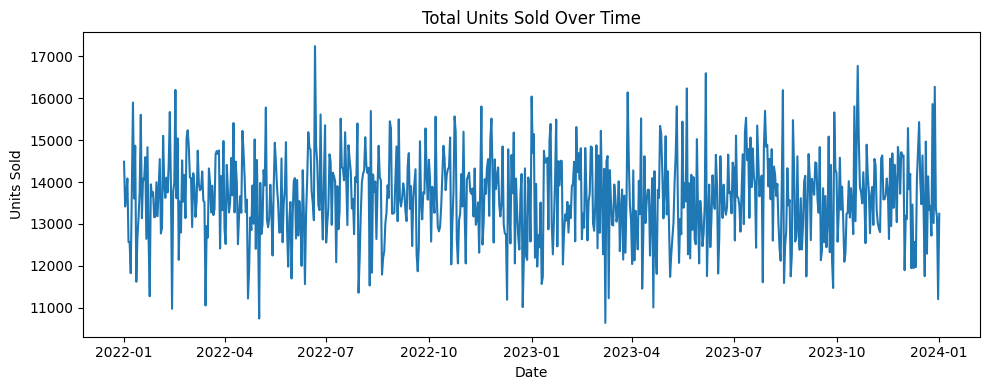

In [39]:
import matplotlib.pyplot as plt

tmp = (
    df.groupby("Date")["Units Sold"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(10,4))
plt.plot(tmp["Date"], tmp["Units Sold"])
plt.title("Total Units Sold Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()

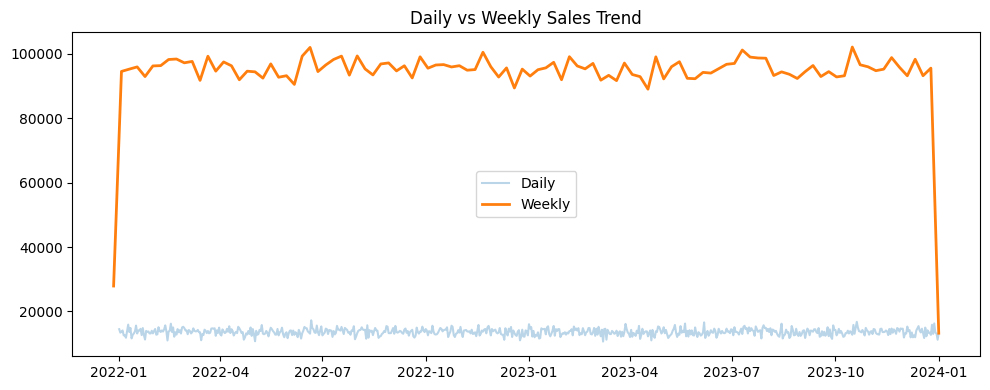

In [40]:
tmp["week"] = tmp["Date"].dt.to_period("W").dt.start_time
weekly = tmp.groupby("week")["Units Sold"].sum().reset_index()

plt.figure(figsize=(10,4))
plt.plot(tmp["Date"], tmp["Units Sold"], alpha=0.3, label="Daily")
plt.plot(weekly["week"], weekly["Units Sold"], linewidth=2, label="Weekly")
plt.legend()
plt.title("Daily vs Weekly Sales Trend")
plt.tight_layout()
plt.show()

Saved mapping for 25 features -> /content/feature_name_mapping.json


,orig,readable
0,Inventory Level,Inventory Level
1,Price,Price
2,Discount,Discount
3,Competitor Pricing,Competitor Pricing
4,Units Ordered,Units Ordered
5,lag_1,Lag 1d (log Units Sold)
6,lag_7,Lag 7d (log Units Sold)
7,lag_14,Lag 14d (log Units Sold)
8,lag_28,Lag 28d (log Units Sold)
9,roll_mean_7,Rolling mean 7d (log Units Sold)


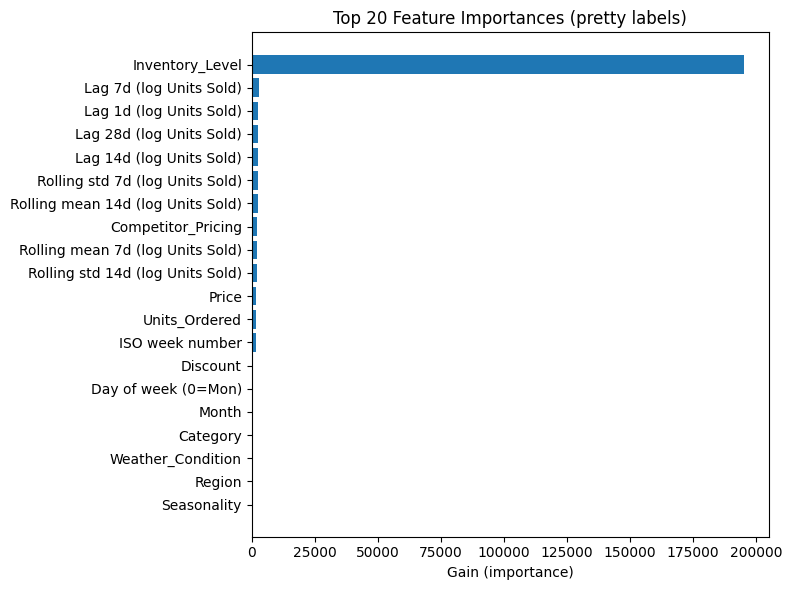

In [41]:
# ===== Feature name prettifier & top-feature visualization =====
# Paste this into a notebook cell (run after you've placed model + features JSON under /content)

import re, json, os
from pathlib import Path
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

# ---- CONFIG: choose model + feature-list you want to prettify/visualize ----
# Change these if you want the other model
MODEL_PATH = "/content/untitled11_checkpoint_lgb.txt"        # daily model file (or change to untitled12...)
FEATURE_PATH = "/content/untitled11_checkpoint_features.json"

# Output mapping file (human-readable)
OUT_MAPPING = "/content/feature_name_mapping.json"

# ---- helper: prettify rules (regex replacement order matters) ----
def prettify_feature_name(f):
    """Turn machine feature name into a readable label (English)."""
    # if it's already human-friendly, return small cleanups
    f = str(f)
    # common prefix/suffix replacements
    f = f.replace("sku_store", "SKU_Store")
    f = f.replace("Store ID_freq", "Store_frequency")
    f = f.replace("Product ID_freq", "Product_frequency")
    # lag features: lag_7 -> Lag 7 days (log Units Sold)
    m = re.match(r"^lag_(\d+)$", f)
    if m:
        d = int(m.group(1))
        return f"Lag {d}d (log Units Sold)"
    # rolling mean/std: roll_mean_7 -> Rolling mean (7d, log Units Sold)
    m = re.match(r"^roll_mean_(\d+)$", f)
    if m:
        w = int(m.group(1))
        return f"Rolling mean {w}d (log Units Sold)"
    m = re.match(r"^roll_std_(\d+)$", f)
    if m:
        w = int(m.group(1))
        return f"Rolling std {w}d (log Units Sold)"
    # days_since_prev
    if f == "days_since_prev":
        return "Days since previous sale"
    # time features
    if f in ("day_of_week",):
        return "Day of week (0=Mon)"
    if f == "is_weekend":
        return "Is weekend"
    if f == "month":
        return "Month"
    if f == "week":
        return "ISO week number"
    # numeric base features
    for col in ["Inventory Level","Price","Discount","Competitor Pricing","Units Ordered"]:
        if f == col:
            return col
    # frequency columns
    if f.endswith("_freq"):
        base = f.replace("_freq","").replace("_"," ")
        return f"{base} frequency"
    # categorical columns (keep readable)
    if f in ["Category","Region","Weather Condition","Seasonality"]:
        return f
    # fallback: replace underscores by spaces, title-case
    cand = f.replace("_"," ").strip()
    cand = re.sub(r"\s+", " ", cand)
    # if it's short like 'y' or 'Units Sold' just return cand
    if len(cand) <= 2:
        return f
    return cand.title()

# ---- load features list ----
if not os.path.exists(FEATURE_PATH):
    raise FileNotFoundError(f"Feature list not found: {FEATURE_PATH}")

with open(FEATURE_PATH,"r") as f:
    orig_features = json.load(f)

# create mapping
mapping = {}
for f in orig_features:
    mapping[f] = prettify_feature_name(f)

# save mapping (human-friendly JSON)
with open(OUT_MAPPING,"w") as f:
    json.dump(mapping, f, indent=2, ensure_ascii=False)

print(f"Saved mapping for {len(mapping)} features -> {OUT_MAPPING}")

# ---- optional: show mapping table (first 50 rows) ----
df_map = pd.DataFrame([
    {"orig": k, "readable": v} for k,v in mapping.items()
])
display(df_map.head(50))

# ---- If model exists, plot top-20 feature importances with pretty labels ----
if os.path.exists(MODEL_PATH):
    bst = lgb.Booster(model_file=MODEL_PATH)
    # get feature names from model; if model has different order, align with mapping where possible
    model_feats = bst.feature_name()
    gains = bst.feature_importance(importance_type="gain")
    fi_df = pd.DataFrame({"feature": model_feats, "gain": gains})
    fi_df = fi_df.sort_values("gain", ascending=False).head(20)
    # map to readable labels (fallback to original if mapping missing)
    fi_df["label"] = fi_df["feature"].map(mapping).fillna(fi_df["feature"])
    # plot
    plt.figure(figsize=(8,6))
    plt.barh(fi_df["label"][::-1], fi_df["gain"][::-1])
    plt.xlabel("Gain (importance)")
    plt.title(f"Top {len(fi_df)} Feature Importances (pretty labels)")
    plt.tight_layout()
    plt.show()
else:
    print("Model file not found at", MODEL_PATH, "- skipping importance plot.")


Rows total / train / valid: 73100 58480 14620
Validation rows: 14620 | RMSE: 95.8942 | MAE: 72.2298


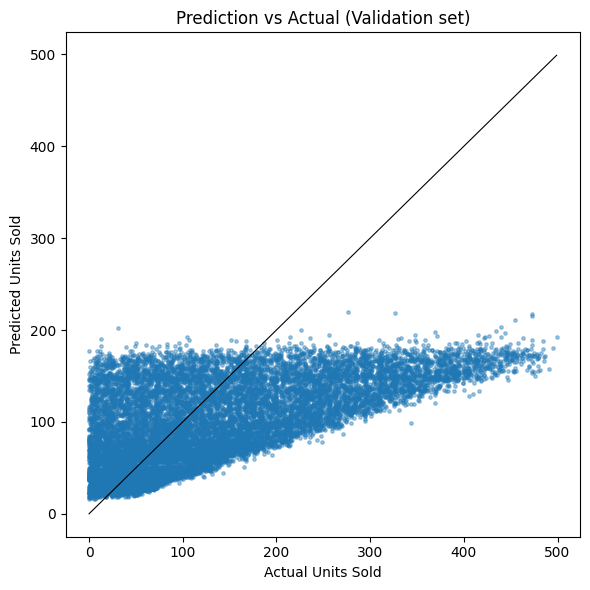

In [42]:
# ===== Recreate features for validation, predict, and plot (one cell you can run) =====
# Paste and run this AFTER you uploaded the CSV and the model + features JSON under /content.

import os, json
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

# -------- CONFIG ----------
DATA_PATH = "/content/retail_store_inventory.csv"
MODEL_PATH = "/content/untitled11_checkpoint_lgb.txt"   # daily model by default
FEATURE_PATH = "/content/untitled11_checkpoint_features.json"
TEST_SIZE_RATIO = 0.2
DO_WEEKLY = False   # <- 如果你想用 weekly model, set True and change MODEL_PATH/FEATURE_PATH accordingly

# If you want weekly mode, uncomment and adjust
# DO_WEEKLY = True
# MODEL_PATH = "/content/untitled12_checkpoint_lgb.txt"
# FEATURE_PATH = "/content/untitled12_checkpoint_features.json"

# -------- helper functions (match your training script) ----------
LAGS = [1, 7, 14, 28]
ROLL_WINDOWS = [7, 14]
DATE_COL = "Date"
TARGET = "Units Sold"
GROUP_KEYS = ["Product ID", "Store ID"]

def create_time_features(df):
    df = df.copy()
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
    df['day_of_week'] = df[DATE_COL].dt.dayofweek.astype('int8')
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype('int8')
    df['month'] = df[DATE_COL].dt.month.astype('int8')
    # ISO week: pandas >= 1.1 returns a Series dtype; convert to int
    df['week'] = df[DATE_COL].dt.isocalendar().week.astype('int16')
    return df

def frequency_encoding(df, cols):
    for c in cols:
        if c in df.columns:
            df[c + '_freq'] = df[c].map(df[c].value_counts(normalize=True))
    return df

def make_lag_features(df, group_cols, target_col='y'):
    # expects df sorted by group_cols + DATE_COL
    df = df.sort_values(group_cols + [DATE_COL]).copy()

    def _make(g):
        g = g.sort_values(DATE_COL)
        for lag in LAGS:
            g[f'lag_{lag}'] = g[target_col].shift(lag)
        for w in ROLL_WINDOWS:
            g[f'roll_mean_{w}'] = g[target_col].shift(1).rolling(window=w, min_periods=1).mean()
            g[f'roll_std_{w}'] = g[target_col].shift(1).rolling(window=w, min_periods=1).std().fillna(0)
        g['days_since_prev'] = (g[DATE_COL] - g[DATE_COL].shift(1)).dt.days.fillna(0)
        return g

    df = df.groupby(group_cols, group_keys=False).apply(_make).reset_index(drop=True)
    return df

# -------- Load raw data ----------
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Data not found at {DATA_PATH}. Please upload CSV to /content")

raw = pd.read_csv(DATA_PATH)
raw[DATE_COL] = pd.to_datetime(raw[DATE_COL], errors="coerce")
raw = raw.dropna(subset=[DATE_COL, TARGET])  # drop rows missing date or target

# -------- If weekly aggregation required (to match weekly model) ----------
if DO_WEEKLY:
    # aggregate similarly to your weekly pipeline
    weekly = (
        raw
        .groupby(GROUP_KEYS + [pd.Grouper(key=DATE_COL, freq='W')], as_index=False)
        .agg({
            TARGET: 'sum',
            'Inventory Level': 'mean',
            'Units Ordered': 'sum',
            'Price': 'mean',
            'Discount': 'max',
            'Competitor Pricing': 'mean',
            'Category': 'first',
            'Region': 'first',
            'Weather Condition': 'first',
            'Seasonality': 'first'
        })
    )
    df_all = weekly.rename(columns={DATE_COL: DATE_COL})
else:
    df_all = raw.copy()

# -------- Sort and split (time-based) ----------
df_all = df_all.sort_values(DATE_COL).reset_index(drop=True)
split_idx = int(len(df_all) * (1.0 - TEST_SIZE_RATIO))
train = df_all.iloc[:split_idx].reset_index(drop=True)
valid = df_all.iloc[split_idx:].reset_index(drop=True)
print("Rows total / train / valid:", len(df_all), len(train), len(valid))

# -------- Create features on the full (train+valid) then keep valid rows ----------
# This ensures lag features are properly computed (they depend on earlier rows)
df_full = pd.concat([train, valid], axis=0).reset_index(drop=True)

# base numeric fills (same as training script)
num_fill_cols = [c for c in ['Price', 'Competitor Pricing', 'Discount', 'Inventory Level', 'Units Ordered'] if c in df_full.columns]
for c in num_fill_cols:
    df_full[c] = df_full[c].fillna(df_full[c].median())

# time features
df_full = create_time_features(df_full)

# frequency encoding
enc_cols = [c for c in ['Store ID', 'Product ID'] if c in df_full.columns]
df_full = frequency_encoding(df_full, enc_cols)

# sku_store freq
if 'Store ID' in df_full.columns and 'Product ID' in df_full.columns:
    df_full['sku_store'] = df_full['Product ID'].astype(str) + '|' + df_full['Store ID'].astype(str)
    df_full['sku_store_freq'] = df_full['sku_store'].map(df_full['sku_store'].value_counts(normalize=True))

# log1p target (for lag computation)
df_full['y'] = np.log1p(df_full[TARGET].astype(float))

# make lag features (group by)
if all(k in df_full.columns for k in GROUP_KEYS):
    df_full = make_lag_features(df_full, GROUP_KEYS, target_col='y')
else:
    # fallback: try group only by Product ID if Store ID missing
    alt_keys = [k for k in GROUP_KEYS if k in df_full.columns]
    if alt_keys:
        df_full = make_lag_features(df_full, alt_keys, target_col='y')
    else:
        raise RuntimeError("Group keys for lag features missing in data: " + str(GROUP_KEYS))

# fill lag/roll NAs with medians / zeros (same as training)
lag_cols = [c for c in df_full.columns if c.startswith('lag_') or c.startswith('roll_')]
for c in lag_cols:
    df_full[c] = df_full[c].fillna(df_full[c].median()).fillna(0)

# cast categorical types (optional)
cat_cols = [c for c in ['Category', 'Region', 'Weather Condition', 'Seasonality'] if c in df_full.columns]
for c in cat_cols:
    df_full[c] = df_full[c].astype('category')

# keep only valid rows for prediction
valid_feat = df_full.iloc[len(train):].reset_index(drop=True)

# -------- Load feature list expected by model ----------
if not os.path.exists(FEATURE_PATH):
    raise FileNotFoundError(f"Feature list not found: {FEATURE_PATH}")

with open(FEATURE_PATH, "r") as f:
    features = json.load(f)

# ensure all features exist in valid_feat (if missing, create safe defaults)
missing = [f for f in features if f not in valid_feat.columns]
if missing:
    print("Warning: following features are missing from data - creating safe defaults:", missing)
    for f in missing:
        # try sensible default: zero or median if similar numeric patterns
        # numeric default: 0 ; if name contains 'freq' use 0; 'lag' use 0
        valid_feat[f] = 0

# re-order columns and select X_valid
X_valid = valid_feat[features].copy()
y_true = valid_feat[TARGET].values  # original scale

# -------- Load model and predict (model predicts log1p(y)) ----------
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model file not found: {MODEL_PATH}")

bst = lgb.Booster(model_file=MODEL_PATH)
pred_log = bst.predict(X_valid, num_iteration=bst.best_iteration if hasattr(bst, "best_iteration") else None)
pred = np.expm1(pred_log)

# -------- Basic metrics ----------
from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = np.sqrt(mean_squared_error(y_true, pred))
mae = mean_absolute_error(y_true, pred)

print(f"Validation rows: {len(y_true)} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")

# -------- Plot prediction vs actual --------
plt.figure(figsize=(6,6))
plt.scatter(y_true, pred, s=6, alpha=0.4)
mn = min(y_true.min(), pred.min())
mx = max(y_true.max(), pred.max())
plt.plot([mn, mx], [mn, mx], color='k', linewidth=0.8)
plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")
plt.title("Prediction vs Actual (Validation set)")
plt.tight_layout()
plt.show()
